In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
t = np.array([0,1,2,3,4,5,6,7,8,9])
q = np.array([1000,920,850,790,740,700,660,630,600,580])

print("Step 1: Loaded historical data")

Step 1: Loaded historical data


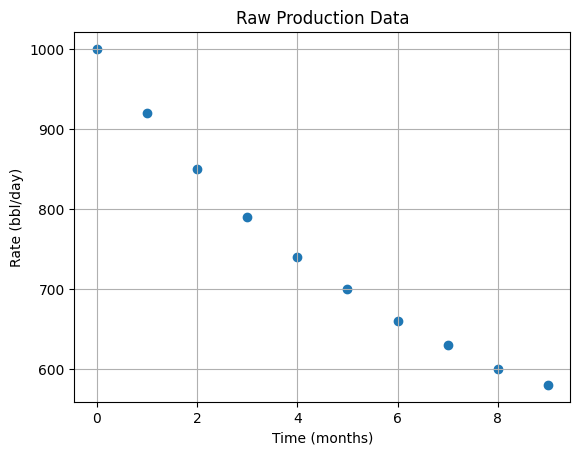

In [18]:
plt.figure()
plt.scatter(t, q)
plt.xlabel("Time (months)")
plt.ylabel("Rate (bbl/day)")
plt.title("Raw Production Data")
plt.grid()
plt.show()


Step 2: Converted to ln(q) for linearization


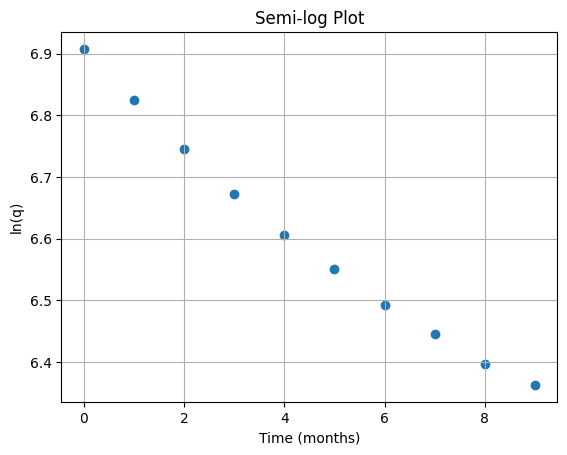

In [17]:
lnq = np.log(q)

print("\nStep 2: Converted to ln(q) for linearization")

# Plot ln(q) vs t
plt.figure()
plt.scatter(t, lnq)
plt.xlabel("Time (months)")
plt.ylabel("ln(q)")
plt.title("Semi-log Plot")
plt.grid()
plt.show()

In [7]:
coeffs = np.polyfit(t, lnq, 1)

slope = coeffs[0]
intercept = coeffs[1]

D_exp = -slope
qi_exp = np.exp(intercept)

print("\nStep 3: Linear regression results")
print("Slope =", slope)
print("Intercept =", intercept)
print("D (decline rate) =", D_exp)
print("qi (initial rate) =", qi_exp)


Step 3: Linear regression results
Slope = -0.06052839100444964
Intercept = 6.872882377357514
D (decline rate) = 0.06052839100444964
qi (initial rate) = 965.7281509367518


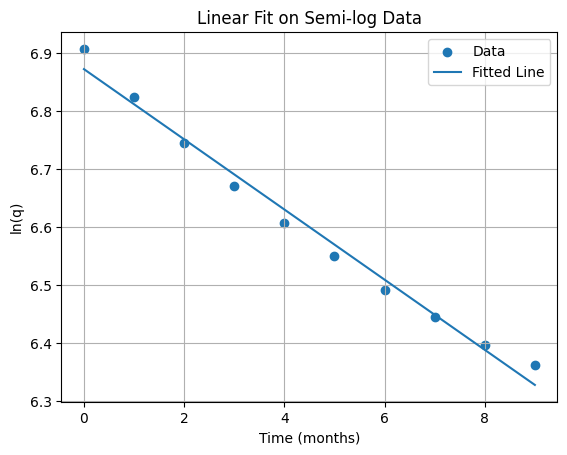

In [16]:
plt.figure()
plt.scatter(t, lnq, label="Data")
plt.plot(t, np.polyval(coeffs, t), label="Fitted Line")
plt.xlabel("Time (months)")
plt.ylabel("ln(q)")
plt.title("Linear Fit on Semi-log Data")
plt.legend()
plt.grid()
plt.show()


Converted back to exponential form


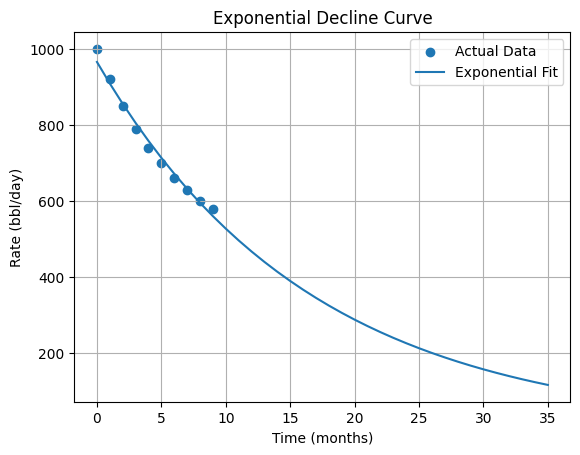

In [15]:
t_future = np.arange(0, 36)
q_exp_forecast = qi_exp * np.exp(-D_exp * t_future)

print("\nConverted back to exponential form")

# Plot exponential curve
plt.figure()
plt.scatter(t, q, label="Actual Data")
plt.plot(t_future, q_exp_forecast, label="Exponential Fit")
plt.xlabel("Time (months)")
plt.ylabel("Rate (bbl/day)")
plt.title("Exponential Decline Curve")
plt.legend()
plt.grid()
plt.show()

In [11]:
def hyperbolic(t, qi, Di, b):
    return qi / (1 + b*Di*t)**(1/b)

params, _ = curve_fit(hyperbolic, t, q, bounds=(0, [2000,1,1]))

qi_hyp, Di_hyp, b_hyp = params

print("\nStep 5: Hyperbolic model parameters")
print("qi =", qi_hyp)
print("Di =", Di_hyp)
print("b =", b_hyp)


Step 5: Hyperbolic model parameters
qi = 994.4469348994987
Di = 0.08310718702218955
b = 0.9999999999999999


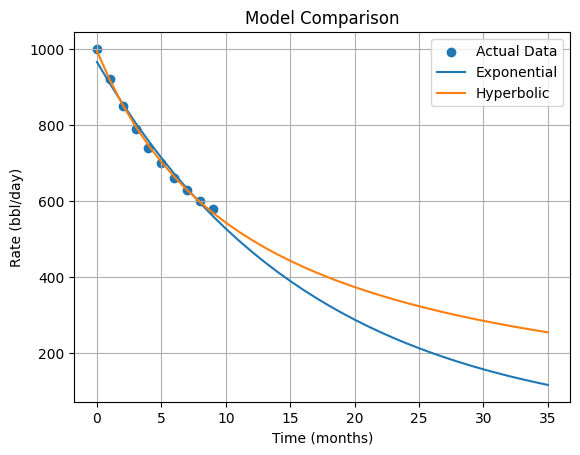

In [13]:
# Hyperbolic forecast
q_hyp_forecast = hyperbolic(t_future, qi_hyp, Di_hyp, b_hyp)

# Plot comparison
plt.figure()
plt.scatter(t, q, label="Actual Data")
plt.plot(t_future, q_exp_forecast, label="Exponential")
plt.plot(t_future, q_hyp_forecast, label="Hyperbolic")
plt.xlabel("Time (months)")
plt.ylabel("Rate (bbl/day)")
plt.title("Model Comparison")
plt.legend()
plt.grid()
plt.show()



Using Harmonic Formula for Np (b ≈ 1)


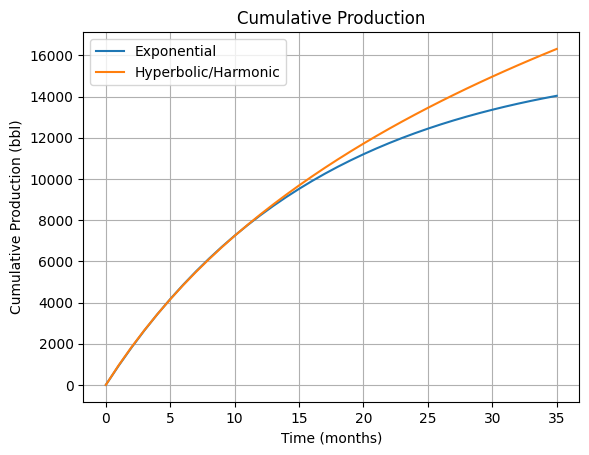

In [19]:
# STEP 6 — CUMULATIVE PRODUCTION

# Exponential
Np_exp = (qi_exp - q_exp_forecast) / D_exp

# Hyperbolic / Harmonic FIX
if abs(b_hyp - 1) < 0.05:
    print("\nUsing Harmonic Formula for Np (b ≈ 1)")
    Np_hyp = (qi_hyp / Di_hyp) * np.log(qi_hyp / q_hyp_forecast)
else:
    Np_hyp = (qi_hyp / (Di_hyp * (1 - b_hyp))) * \
             (1 - (q_hyp_forecast / qi_hyp)**(1 - b_hyp))

plt.figure()
plt.plot(t_future, Np_exp, label="Exponential")
plt.plot(t_future, Np_hyp, label="Hyperbolic/Harmonic")
plt.xlabel("Time (months)")
plt.ylabel("Cumulative Production (bbl)")
plt.title("Cumulative Production")
plt.legend()
plt.grid()
plt.show()

In [20]:
# EUR CALCULATION

q_econ = 100

# Exponential EUR
EUR_exp = (qi_exp - q_econ) / D_exp

# Hyperbolic / Harmonic EUR
if abs(b_hyp - 1) < 0.05:
    EUR_hyp = (qi_hyp / Di_hyp) * np.log(qi_hyp / q_econ)
else:
    EUR_hyp = (qi_hyp / (Di_hyp * (1 - b_hyp))) * \
              (1 - (q_econ / qi_hyp)**(1 - b_hyp))

print("\nEUR Results:")
print("Exponential EUR =", EUR_exp)
print("Hyperbolic/Harmonic EUR =", EUR_hyp) 


EUR Results:
Exponential EUR = 14302.844278036555
Hyperbolic/Harmonic EUR = 27485.722374983823


In [21]:
# STEP 8 — ERROR COMPARISON (OPTIONAL BUT STRONG)

error_exp = np.sum((q - qi_exp*np.exp(-D_exp*t))**2)
error_hyp = np.sum((q - hyperbolic(t, qi_hyp, Di_hyp, b_hyp))**2)

print("\nModel Error Comparison:")
print("Exponential Error =", error_exp)
print("Hyperbolic Error =", error_hyp)


Model Error Comparison:
Exponential Error = 2633.0891749353436
Hyperbolic Error = 268.53712941443223
